## Comparison FLR - SIM

In [1]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from h5py import File
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source_index = 6

In [3]:
scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'

L1_file_path = f'{scratch}/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5'

In [5]:
import glob
import os

scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'
source_index = 6

# Use * as a wildcard for the parts that change
pattern = os.path.join(scratch, f'EMRI_731d_2.5s_L1_source{source_index}_*.h5')
files = glob.glob(pattern)

if files:
    # If multiple versions, sort on stimestamps
    L1_file_path = sorted(files)[-1] 
    print(f"Selected: {L1_file_path}")
else:
    print("No file found for that source index.")

Selected: /scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5


In [6]:
from mojito import MojitoL1File    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

281600000000000.0


In [5]:
dt = delta_t = tdi_dt
tdi_dt

2.5

In [6]:
x2.shape

(25246480,)

In [7]:
len_waveform = int(x2.shape[0] + 2* (550/dt + 1000))
len_waveform

25248920

The difference in the length of the simulation and the length of the generated waveform: 

In [8]:
25248920 - 25246480

2440

This is the extra part of the waveform that we need to generate: given as a number of samples

In [9]:
2* (550/dt + 1000)

2440.0

In [10]:
Time = len_waveform / ASTRONOMICAL_YEAR *dt

In [11]:
tdi_time_sampling.t0

97729939.827664

In [12]:
def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )


In [13]:
# create timing dictionary

t_dltt_orbits = 10.
dt_orbits = 5e5
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"

In [14]:
dt_orbits

500000.0

In [15]:
timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [16]:
timing

{'dt': 2.5,
 't_dltt_orbits': 10.0,
 'dt_orbits': 500000.0,
 't_strain_offset': 550,
 'n_trim_lolipops': 1000,
 'n_orbit_buffer': 10,
 'window_jaxgbresponse': 0.5,
 't0_orbits': 61171239.327664,
 'size_l1': 25246521,
 'size_l0': 25248521,
 'size_strain': 25248961,
 'size_orbits': 274,
 't0_l0': 97731890.577664,
 't_init': 97731340.577664}

In [17]:
# timing
t0_l1 = tdi_time_sampling.t0
t0_l0 = t0_l1 - 1000*dt
t_init = t0_l0 - 550 

In [18]:
print(f'''
t0_l1 = {t0_l1}
t0_l0 = {t0_l0}
t_init = {t_init}
''')


t0_l1 = 97729939.827664
t0_l0 = 97727439.827664
t_init = 97726889.827664



## Build waveform object
Set up the waveform object with right keywords

In [19]:
from fastlisaresponse.utils.parallelbase import ParallelModuleBase
# Create EMRIWave object
sum_kwargs = {
    "pad_output": True,
}

inspiral_kwargs = {
    "DENSE_STEPPING": 0,  # sparsely sampled trajectory
    "max_init_len": int(1e8),  # length of trajectories well under 1000
}

amplitude_kwargs = {
    # "max_init_len": int(1e8),  # all of the trajectories will be well under len = 1000
    # "use_gpu": True,
    # "file_dir":"/data/leuven/367/vsc36785/LISA/FastEMRIWaveforms/data"
}

waveform_kwargs = {
    'mode_selection_threshold': 0.0
}

In [20]:
class EMRIWave_base(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 strain_only=False,
                 time=2.0
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator

        self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        self.t_init = t_init
        self.t0_orbits = t0_orbits
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = T
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        return strain

In [21]:
orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

f_s = 1/dt   
home_folder = os.getcwd()

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [22]:
emri_waveform = EMRIWave_base(use_gpu=use_gpu, 
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=False,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=550, # seconds
                        )

#### old wavefrom object

In [16]:
class EMRIWave(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 T_smooth=0, 
                 model='Kerr',
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 strain_only=False,
                 time=2.0
                #  tdi_offset=250  # seconds
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.T_smooth = T_smooth
        self.model = model
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator
        if self.model == 'Kerr':
            self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        elif self.model == 'AAK':
            self.waveform_gen = GenerateEMRIWaveform(
                    'Pn5AAKWaveform',
                    return_list=False,
                    inspiral_kwargs=inspiral_kwargs,
                    sum_kwargs=sum_kwargs,
                    frame='detector'
            )
        else: 
            raise ValueError(f'{self.model} is not valid. Options are Kerr and AAK') 
            
        # get smooth window function 
        if T_smooth != 0.0:
            self.num_pts = int(self.T_smooth/dt)
            self.window = cp.asarray(tukey(2*self.num_pts, alpha=1, sym=True)[self.num_pts:])
    
        self.dt = dt 
        # define timing
        self.strain_only = strain_only
        if strain_only == True:
            self.n_samples = 0
            self.t0_flr = 0
            self.offset = 0
            self.time = None
        else:
            self.initial_zeros = cp.zeros(int(
                np.ceil((t_init - t0_orbits)/dt)
                ))
            
            self.n_samples = n_samples
            self.offset = offset
            self.time = time
    
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]
    
    @property
    def initial_zeros_length(self):
        return len(self.initial_zeros)

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        if self.time is not None:
            Tobs = self.time
        else:
            Tobs = T

        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = Tobs
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        if self.T_smooth != 0.0:
            padding_index = self.get_pad_index(strain)
            if padding_index != len(strain):
                start_ind = padding_index-self.num_pts
                end_ind = padding_index 
                strain[start_ind:end_ind] = strain[start_ind:end_ind] * self.window
        if self.strain_only:
            # return strain generated for the requested time window
            return strain
        else:
            # return strain on a larger time grid for compatibility with response computation
            
            initial_strains = cp.concatenate((self.initial_zeros, strain, self.initial_zeros), axis=0)
            return initial_strains
            # # pad the initial_strains array with zeros to ensure it is long enough for response computation
            # return cp.pad(initial_strains, (0, len(initial_strains)+ len(self.initial_zeros)), axis=0)

In [31]:
orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [21]:
emri_waveform = EMRIWave(use_gpu=use_gpu, 
                         T_smooth=t_smooth, 
                         model=waveform_model,
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=False,
                         t0_orbits=t0_orbits,
                         t_init=t0_l0 - offset,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=offset, # seconds
                         time=Time   # time for which we generate the waveform
                        )

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


## Get source parameters
get the source parameters from the catalog

In [23]:
from mojito.download import get_source_params

# Get source parameters for mbhb brick, source ID 12
params = get_source_params("emri", source_id=source_index, username='bert-depoorter', token='2c7#QBB9DTh8QgJPpw')

WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


In [24]:
params

{'AzimuthalAnglePrimarySpin': np.float64(3.849520179081373),
 'AzimuthalPhase': np.float64(3.1939745793887977),
 'ChirpMassSSBFrame': np.float64(3364.153490238571),
 'Declination': np.float64(0.7313689457484064),
 'Eccentricity': np.float64(0.7439559287139789),
 'EstimatedSNR': np.float64(95.84905866519384),
 'ID': np.int64(7),
 'InclinationAngle': np.float64(0.0),
 'LuminosityDistance': np.float64(4755.290534781199),
 'MassRatio': np.float64(0.000146453721146835),
 'PolarAnglePrimarySpin': np.float64(1.1706519351964189),
 'PolarPhase': np.float64(3.3779647386796587),
 'PrimaryMassSSBFrame': np.float64(672153.2079661994),
 'PrimaryMassSourceFrame': np.float64(382296.2157652893),
 'PrimarySpinParameter': np.float64(0.5),
 'RadialPhase': np.float64(0.6038015447102911),
 'Redshift': np.float64(0.7582000036821386),
 'RightAscension': np.float64(3.9684956565955574),
 'SecondaryMassSSBFrame': np.float64(98.43933848743235),
 'SecondaryMassSourceFrame': np.float64(55.98870337917995),
 'SemiLat

In [25]:
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

In [26]:
ra = params['RightAscension']
dec = params['Declination']

lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl


In [27]:
# extract source parameters
params_mojito = [
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'],
    params['SemiLatusRectum'],
    params['Eccentricity'],
    np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,  # np.pi/2 - beta
    phiS_ecl,  # lambda
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    params['PolarPhase'],
    params['RadialPhase'],
]

### test waveform module

In [28]:
emri_test = emri_waveform(*params_mojito, T = 2, dt=dt)

(36900450.53134839, 36902664.66908716)

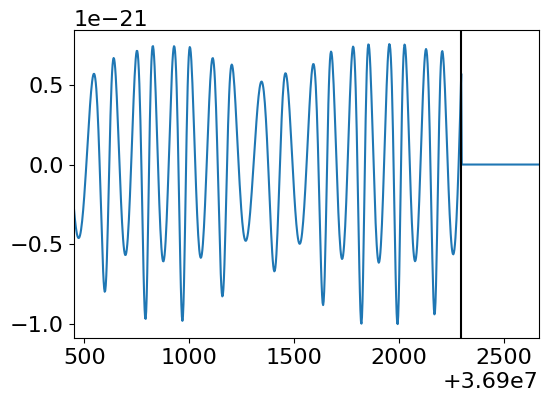

In [29]:
time = np.arange(len(emri_test)) * dt

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(time, emri_test.real.get())
ax.axvline(params['TimeCoalescenceSSBFrame'], color='black')

ax.set_xlim([0.99995* params['TimeCoalescenceSSBFrame'], 1.00001*params['TimeCoalescenceSSBFrame']])

In [30]:
orbit_file= f'{home_folder}/esa-trailing-orbits-mojito_validation_test_2.h5'
force_backend = 'cuda12x'
esa = Orbits(filename=orbit_file, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False,
            t0=t0_orbits)

In [31]:
len(params_mojito)

14

In [32]:
force_backend = "cuda12x" if use_gpu else None

index_beta = 7
index_lambda = 8

tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,
}

In [33]:
from fastlisaresponse.tdiconfig import TDIConfig
tdi_kwargs_esa = dict(
            orbits=esa,
            order=40,
            tdi=TDIConfig('2nd generation'),
            tdi_chan="XYZ",
        )

In [34]:
Tobs = 2 # years
offset = 550
n_samples = 1000
T = Tobs + (2* offset + 2*n_samples*dt)/ASTRONOMICAL_YEAR


In [35]:
emri_TDI_list = ResponseWrapper(
    emri_waveform,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t_init,
    t_buffer = 10000.0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=False,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    # orbits=esa,
    **tdi_kwargs_esa,
)

In [36]:
def emri_TDI(*params):
    return cp.asarray(emri_TDI_list(*params))

In [37]:
chans = emri_TDI(*params_mojito)

In [38]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

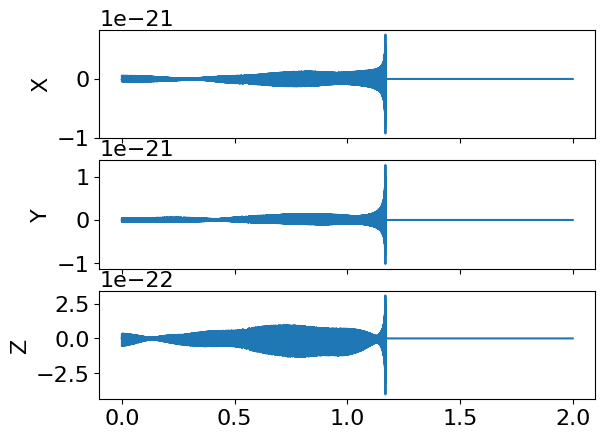

In [39]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

In [40]:
chans.shape

(3, 25248959)

In [41]:
x2.shape

(25246480,)

In [61]:
25248959 - 25246480

2479

In [62]:
850.5 / dt

340.2

In [ ]:
# crop chans
chans_cropped = 

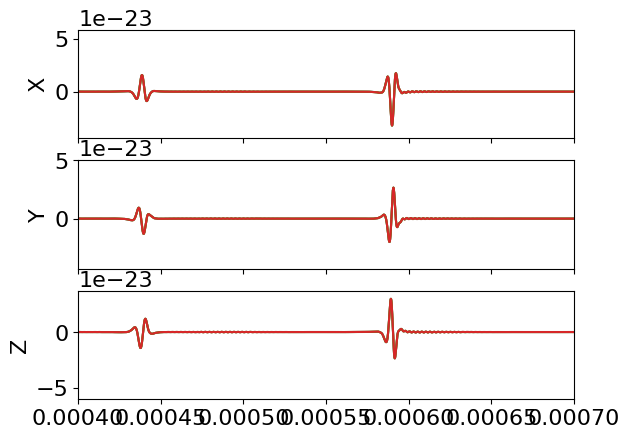

In [49]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[:10000], chans[i].get()[:10000])
    ax[0].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, x2[:10000])
    ax[1].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, y2[:10000])
    ax[2].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, z2[:10000])
    ax[i].set_xlim([0.0004, 0.0007])
    ax[i].set_ylabel(lab)

## Comparison plots

In [57]:
time_sim_L1 = np.arange(t_init + 850.5, x2.shape[0]*delta_t + t_init + 850.5, dt)[:-1] / YRSID_SI 
time_flr_L1 = np.arange(t_init, chans.shape[1]*delta_t + t_init, dt)[:-1] /YRSID_SI

In [58]:
len(chans[0])


25248959

In [59]:
time_flr_L1.shape

(25248959,)

Text(0.5, 1.0, 'TDI X channel')

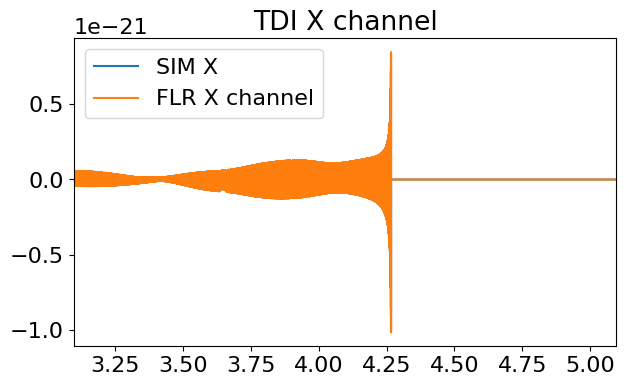

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, x2, label='SIM X')   
ax.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

Text(0.5, 1.0, 'TDI Y channel')

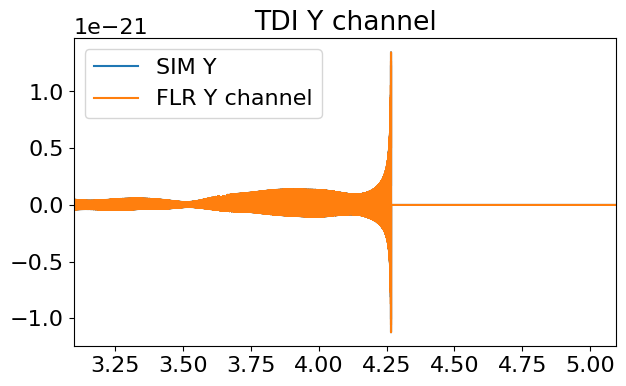

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, y2, label='SIM Y')   
ax.plot(time_flr_L1, chans[1].get(), label='FLR Y channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Z channel')

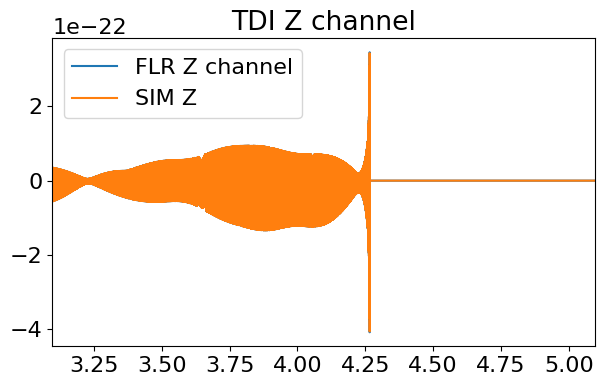

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.plot(time_sim_L1, z2, label='SIM Z')   
# ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

Text(0.5, 1.0, 'TDI X channel')

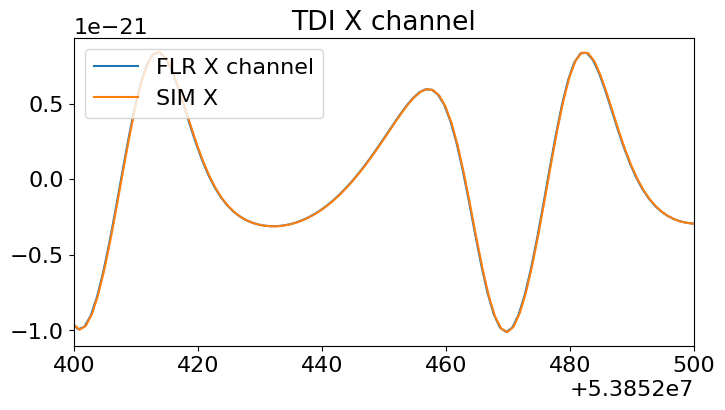

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))


ax.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax.set_xlim([5.38524e7,5.38525e7 ])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

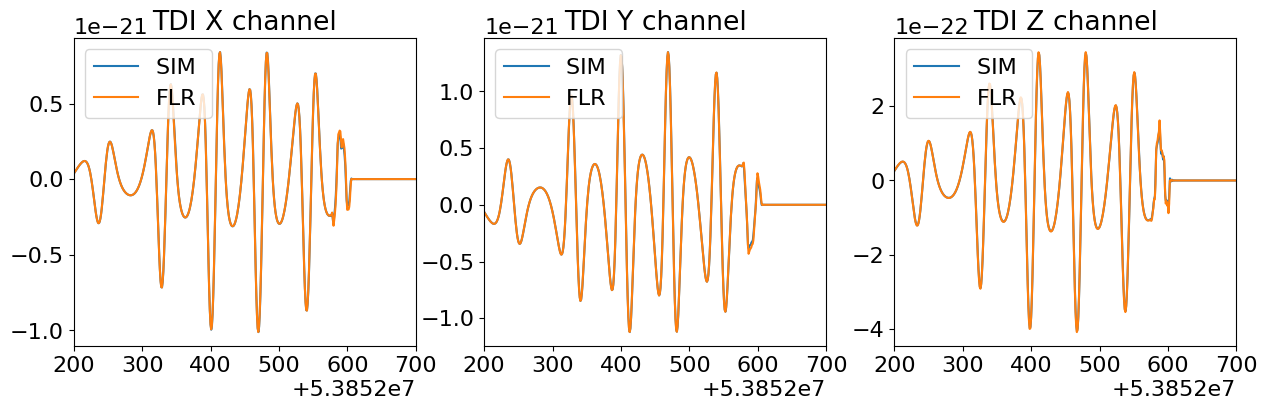

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1*YRSID_SI/dt, sim_data[i], label=f'SIM ')   
    ax[i].plot(time_flr_L1*YRSID_SI/dt, chans[i].get(), label=f'FLR')
    ax[i].set_xlim([5.38522e7,5.38527e7 ])
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

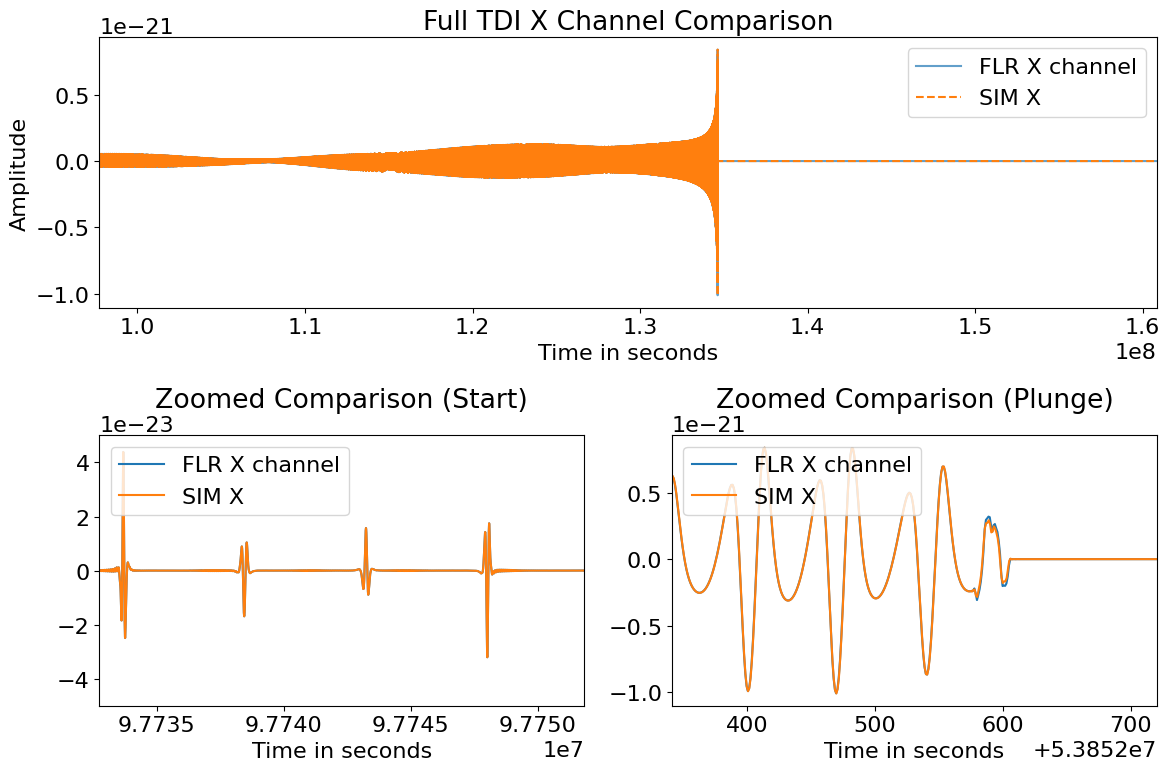

In [49]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# panel with full thing
ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
ax_top.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel', alpha=0.7)
ax_top.plot(time_sim_L1*YRSID_SI, x2, label='SIM X', linestyle='--')
ax_top.set_xlim([time_sim_L1[0]*YRSID_SI, time_sim_L1[-1]*YRSID_SI])
ax_top.set_title('Full TDI X Channel Comparison')
ax_top.legend(loc='upper right')
ax_top.set_xlabel('Time in seconds')
ax_top.set_ylabel('Amplitude')

# bottom left
ax_left = fig.add_subplot(gs[1, 0])
ax_left.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel')
ax_left.plot(time_sim_L1*YRSID_SI, x2, label='SIM X')   
ax_left.set_xlim([(time_sim_L1[0])*YRSID_SI+1000*dt, (time_sim_L1[0]+ 0.00005)*YRSID_SI+8000*dt])
ax_left.set_ylim([-5e-23, 5e-23])
ax_left.legend(loc='upper left')
ax_left.set_xlabel('Time in seconds')
ax_left.set_title('Zoomed Comparison (Start)')

# Bottom right
ax_right = fig.add_subplot(gs[1, 1])
ax_right.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax_right.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
ax_right.legend(loc='upper left')
ax_right.set_xlabel('Time in seconds')
ax_right.set_title('Zoomed Comparison (Plunge)')

plt.tight_layout()
plt.show()

In [56]:
chans[0].shape[0] - x2.shape[0]

2440

In [54]:
x2.shape

(25246480,)

In [55]:
302.5/2.5

121.0

In [59]:
chans_clipped = chans[:, int(550/dt + 1000): -int(550/dt + 1000)]
chans_clipped.shape

(3, 25246480)

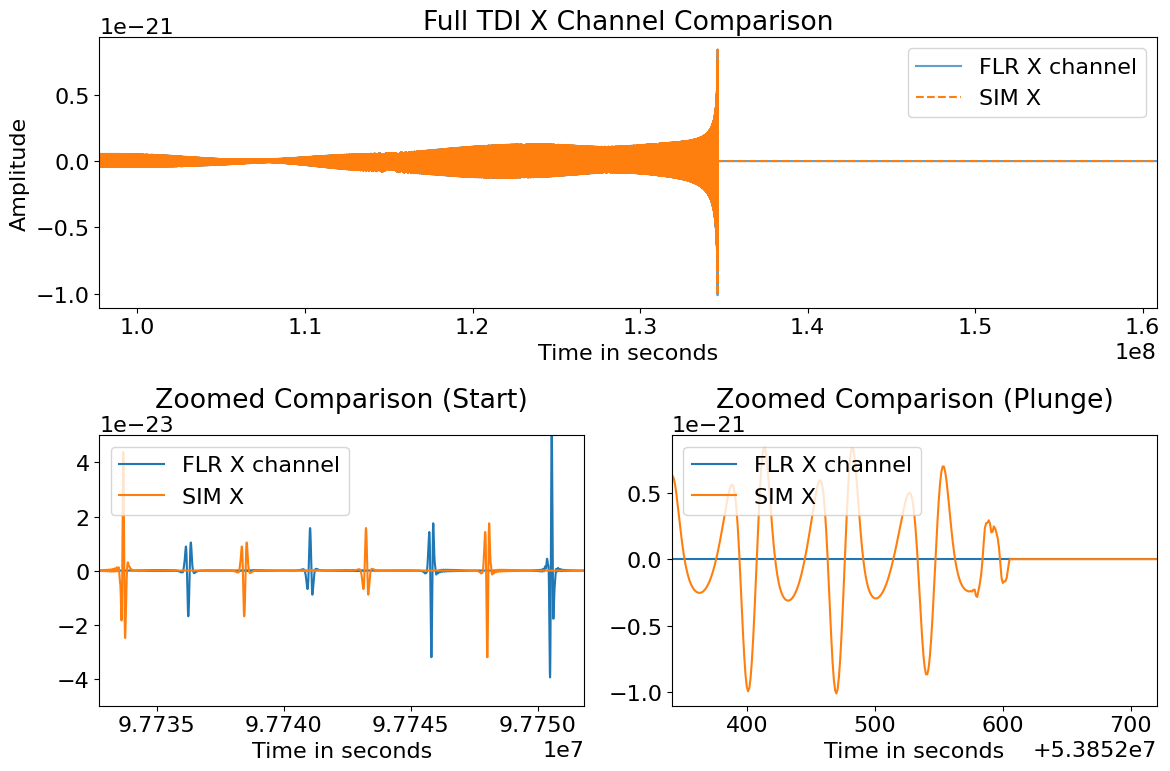

In [60]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# panel with full thing
ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
ax_top.plot(time_sim_L1*YRSID_SI, chans_clipped[0].get(), label='FLR X channel', alpha=0.7)
ax_top.plot(time_sim_L1*YRSID_SI, x2, label='SIM X', linestyle='--')
ax_top.set_xlim([time_sim_L1[0]*YRSID_SI, time_sim_L1[-1]*YRSID_SI])
ax_top.set_title('Full TDI X Channel Comparison')
ax_top.legend(loc='upper right')
ax_top.set_xlabel('Time in seconds')
ax_top.set_ylabel('Amplitude')

# bottom left
ax_left = fig.add_subplot(gs[1, 0])
ax_left.plot(time_sim_L1*YRSID_SI, chans_clipped[0].get(), label='FLR X channel')
ax_left.plot(time_sim_L1*YRSID_SI, x2, label='SIM X')   
ax_left.set_xlim([(time_sim_L1[0])*YRSID_SI+1000*dt, (time_sim_L1[0]+ 0.00005)*YRSID_SI+8000*dt])
ax_left.set_ylim([-5e-23, 5e-23])
ax_left.legend(loc='upper left')
ax_left.set_xlabel('Time in seconds')
ax_left.set_title('Zoomed Comparison (Start)')

# Bottom right
ax_right = fig.add_subplot(gs[1, 1])
ax_right.plot(time_sim_L1*YRSID_SI/dt, chans_clipped[0].get(), label='FLR X channel')
ax_right.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
ax_right.legend(loc='upper left')
ax_right.set_xlabel('Time in seconds')
ax_right.set_title('Zoomed Comparison (Plunge)')

plt.tight_layout()
plt.show()

### Mismatch and SNR computations

In [52]:
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.sensitivity import SensitivityMatrix

from lisatools.domains import TDSettings, FDSettings, FDSignal, TDSignal

In [ ]:
# select the part of the signal above t0

mask = slice(None) #slice(gar_samples, -gar_samples) if remove_garbage else slice(None)

times_waveform_here = times_waveform[mask]

tdi_channels_here = np.array([tdi_channel.get()[mask] for tdi_channel in tdi_channels])

In [ ]:
# now spline interpolate the tdi channels to the same time array as the data
from scipy.interpolate import CubicSpline
window = tukey(len(times_waveform_here), alpha=0.01)

xyz_splined = np.array([
    CubicSpline(times_waveform_here, tdi_channel_here)(loader.times) for tdi_channel_here in tdi_channels_here
])

In [ ]:
NPLOT = int(1e9)

plt.plot(loader.times[:NPLOT], loader.data[0][:NPLOT], label='L1 X')
plt.plot(loader.times[:NPLOT], xyz_splined[0][:NPLOT], alpha=0.7, label='EMRI waveform X', c='k', ls='--')


In [ ]:
xyz_residual = loader.data - xyz_splined

In [ ]:
times_waveform = loader.times.copy()

wf_td_settings = TDSettings(
    t0=times_waveform[0],
    dt=dt,
    N=len(times_waveform)
)

fd_settings = FDSettings(
    min_freq=1e-5,
    max_freq=0.2,
    df= 1 / (wf_td_settings.N * wf_td_settings.dt),
    N= wf_td_settings.N // 2 + 1,
)

In [ ]:
from lisatools.utils.utility import tukey

alpha = 0.01

window = tukey(wf_td_settings.N, alpha=alpha, xp=np)

In [ ]:
wf_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=xyz_splined, settings=wf_td_settings),
    signal_domain=fd_settings,
    window=window
)

data_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=loader.data, settings=wf_td_settings),
    signal_domain=fd_settings,
    window=window
)

residuals_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=xyz_residual, settings=wf_td_settings),
    signal_domain=fd_settings,
    window=window
)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8), sharex=True, sharey=True)

axs = list(axs)

data_res_arr.loglog(fig=fig, ax=axs, label='Data')
wf_res_arr.loglog(fig=fig, ax=axs, label='WF + FLR', c='k', ls='--', alpha=0.8)
residuals_res_arr.loglog(fig=fig, ax=axs, c='gray', alpha=0.8, zorder=0)

# add noise estimates

for i in range(3):
    axs[i].loglog(noise_freqs, xyz_noise_estimate[:, i, i] ** 0.5, c='red', ls=':')

axs[0].set_title("X channel")
axs[1].set_title("Y channel")
axs[2].set_title("Z channel")

axs[0].set_xlabel("Frequency [Hz]")
axs[0].set_ylabel("ASD [1/sqrt(Hz)]")

plt.legend(loc='lower left')
plt.ylim(1e-26, 1e-17)

plt.show()
#plt.xlim(1e-5, 0.2)

In [ ]:
freqs = wf_res_arr.settings.f_arr

In [ ]:
# now compute the covariance matrix at these frequencies

splined_noise_psd = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, i])(freqs) for i in range(3)
])

splined_noise_csd_real = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].real)(freqs) for i in range(3) for j in range(i, 3)
])

splined_noise_psd_imag = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].imag)(freqs) for i in range(3) for j in range(i, 3)   
])

In [ ]:
# now re-assemble the covariance matrix
covariance_matrices = np.zeros((3, 3, len(freqs)), dtype=complex)
for i in range(3):
    covariance_matrices[i, i, :] = splined_noise_psd[i]
    for j in range(i+1, 3):
        covariance_matrices[i, j, :] = splined_noise_csd_real[i*3 + j - (i+1)*i//2] + 1j * splined_noise_psd_imag[i*3 + j - (i+1)*i//2]
        covariance_matrices[j, i, :] = np.conj(covariance_matrices[i, j, :])

In [50]:
t0_orbits

61171239.327664

In [49]:
params['TimeCoalescenceSSBFrame']

np.float64(57519947.48327901)

In [ ]:
57519947.48327901
61171239.327664

In [50]:
t0_l0+322.5

97730262.327664

### Quantitative comparison

In [1]:
import numpy as np
from few.waveform import GenerateEMRIWaveform
from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits

# ──────────────────────────────────────────────
# 1.  Setup observation parameters
# ──────────────────────────────────────────────
Tobs  = 1.0       # observation time in years
dt    = 10.0      # sampling cadence in seconds
t0    = 0.0       # waveform start time in seconds (absolute SSB time)
t_buffer = 10000.0  # buffer time in seconds to discard transient garbage

# ──────────────────────────────────────────────
# 2.  Create the EMRI waveform generator
# ──────────────────────────────────────────────
#     GenerateEMRIWaveform returns hp - i*hx by default,
#     which is exactly what ResponseWrapper expects.
#
#     "FastSchwarzschildEccentricFlux" is Schwarzschild eccentric;
#     swap for "Pn5AAKWaveform" or "FastKerrEccentricEquatorialFlux"
#     as needed.
emri_waveform = GenerateEMRIWaveform(
    "FastSchwarzschildEccentricFlux",
    frame="detector",        # produce waveform in SSB / detector frame
    return_list=False,       # return hp - i*hx  (single complex array)
)

# ──────────────────────────────────────────────
# 3.  Set up orbits (lisa_on_fly branch)
# ───���──────────────────────────────────────────
#     The lisa_on_fly branch of LISAanalysistools adds a `t0` kwarg
#     to the Orbits constructor so the orbit time grid is offset.
#     The `configure(linear_interp_setup=True)` call builds the
#     dense linear-interpolation grid used by the C++ backend.
orbits = EqualArmlengthOrbits(t0=t0)
orbits.configure(linear_interp_setup=True)

# ──────────────────────────────────────────────
# 4.  Build the ResponseWrapper
# ──────────────────────────────────────────────
#     The ResponseWrapper ties together:
#       • waveform generator  (emri_waveform)
#       • observation setup   (Tobs, dt)
#       • sky-coordinate indices in the parameter list
#       • t0 / t_buffer for on-the-fly time offsetting
#       • orbits object
#
#     GenerateEMRIWaveform.__call__ signature:
#       (m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK,
#        Phi_phi0, Phi_theta0, Phi_r0,  *add_args, **kwargs)
#
#       index 0 : m1          index 7 : qS  (ecliptic colatitude of source)
#       index 1 : m2          index 8 : phiS (ecliptic longitude of source)
#       ...                   ...
#
#     ResponseWrapper reads ecliptic longitude from index_lambda
#     and ecliptic latitude from index_beta.
#
#     For GenerateEMRIWaveform:
#       • phiS  (ecliptic longitude λ)  → index 8
#       • qS    (ecliptic colatitude θ) → index 7
#
#     qS is a colatitude (polar angle), not latitude, so we set
#     is_ecliptic_latitude=False to have the wrapper do β = π/2 − qS.

response_wrapper = ResponseWrapper(
    emri_waveform,
    Tobs,
    dt,
    index_lambda=8,                # phiS position in the arg list
    index_beta=7,                  # qS  position in the arg list
    t0=t0,                         # initial time offset
    t_buffer=t_buffer,             # garbage-removal buffer (seconds)
    flip_hx=True,                  # FEW returns hp - i*hx; wrapper expects hp + i*hx
    remove_sky_coords=False,       # keep sky coords (FEW needs them internally)
    is_ecliptic_latitude=False,    # qS is colatitude, not latitude
    remove_garbage="zero",         # zero out edges instead of truncating (good for PE)
    orbits=orbits,
)

# ──────────────────────────────────────────────
# 5.  Define EMRI source parameters
# ──────────────────────────────────────────────
M        = 1e6      # primary mass  [M_sun]
mu       = 10.0     # secondary mass [M_sun]
a        = 0.0      # spin (0 for Schwarzschild)
p0       = 12.0     # initial semi-latus rectum [M]
e0       = 0.3      # initial eccentricity
x0       = 1.0      # cos(inclination); +1 = prograde equatorial
dist     = 1.0      # luminosity distance [Gpc]

qS       = np.pi / 3       # ecliptic colatitude of source [rad]
phiS     = np.pi / 4       # ecliptic longitude of source  [rad]
qK       = np.pi / 4       # spin polar direction  [rad]
phiK     = np.pi / 6       # spin azimuthal direction [rad]
Phi_phi0   = 0.0            # initial azimuthal phase
Phi_theta0 = 0.0            # initial polar phase (ignored for Schwarzschild)
Phi_r0     = 0.0            # initial radial phase

# ──────────────────────────────────────────────
# 6.  Generate TDI channels
# ──────────────────────────────────────────────
#     The wrapper:
#       a) calls emri_waveform(M, mu, a, p0, …, T=Tobs, dt=dt)
#       b) feeds the complex waveform into pyResponseTDI.get_projections(…, t0, t_buffer)
#       c) computes TDI delays  → returns [X, Y, Z] (or [A, E, T])
tdi_channels = response_wrapper(
    M, mu, a, p0, e0, x0, dist,
    qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
)

X, Y, Z = tdi_channels

print(f"TDI channel shapes: X={X.shape}, Y={Y.shape}, Z={Z.shape}")
print(f"Max |X|: {np.max(np.abs(X)):.3e}")

# ──────────────────────────────────────────────
# 7.  (Optional) Quick sanity plot
# ──────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt

    YRSID_SI = 31558149.763545603
    n_pts = len(X)
    t_plot = np.arange(n_pts) * dt / YRSID_SI  # time in years

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, chan, label in zip(axes, [X, Y, Z], ["X", "Y", "Z"]):
        ax.plot(t_plot, chan, linewidth=0.3)
        ax.set_ylabel(label)
    axes[-1].set_xlabel("Time [yr]")
    fig.suptitle("EMRI TDI channels (tdi_on_fly + lisa_on_fly)")
    plt.tight_layout()
    plt.savefig("emri_tdi_channels.png", dpi=150)
    plt.show()
except ImportError:
    print("matplotlib not available — skipping plot.")

/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/fastlisaresponse/response.py:647: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  This class takes a waveform generator that produces :math:`h_+ \pm ih_x`.


AssertionError: 